# Fig. S2 and S3: unlabeled scVIVA, ablations and hyperparameter sensitivity (MERFISH mouse brain)

Inputs:
- `python runner.py merfish_brain/ablation` → ablation and K/β tables (Fig. S3)
- `(cd merfish_brain/unlabeled && python runner_no_labels.py)` → unlabeled scVIVA tables and h5ad (Fig. S2)
- `python runner.py merfish_brain/Figure_2` → the labeled scVIVA reference (Fig. S2B-C)

In [1]:
import importlib.util
import os

import matplotlib.pyplot as plt
import numpy as np
import colorcet as cc
import pandas as pd
import scanpy as sc

plt.rcParams["svg.fonttype"] = "none"
sc.set_figure_params(dpi=150, fontsize=12, format="svg")

REPO = "/home/nathanl/scviva_paper"
TABLES = f"{REPO}/merfish_brain/figures/revisions_benchmark"  # ablation, K/beta and unlabeled tables
FIGURE_2 = f"{REPO}/merfish_brain/Figure_2/figures"  # labeled scVIVA (main benchmark)
FIGURES_DIR = TABLES
NICHEVI_KEY = "s10_scanvi_lr0.0005_poisson_X_nicheVI"

# Leiden resolution of the unlabeled run, from merfish_brain/unlabeled/params.py
_spec = importlib.util.spec_from_file_location("unlabeled_params", f"{REPO}/merfish_brain/unlabeled/params.py")
unlabeled_params = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(unlabeled_params)
FIGURE_RES = unlabeled_params.setup.FIGURE_LEIDEN_RES  # (0.15, 0.35)
print("unlabeled scVIVA at Leiden resolutions", FIGURE_RES)


def read_scib(path):
    """scib-metrics summary table -> float DataFrame indexed by embedding."""
    df = pd.read_csv(path).set_index("Embedding").drop("Metric Type", errors="ignore")
    return df.astype(float)

unlabeled scVIVA at Leiden resolutions (0.15, 0.35)


## Fig. S3: ablation of the niche decoders and sensitivity to K and β

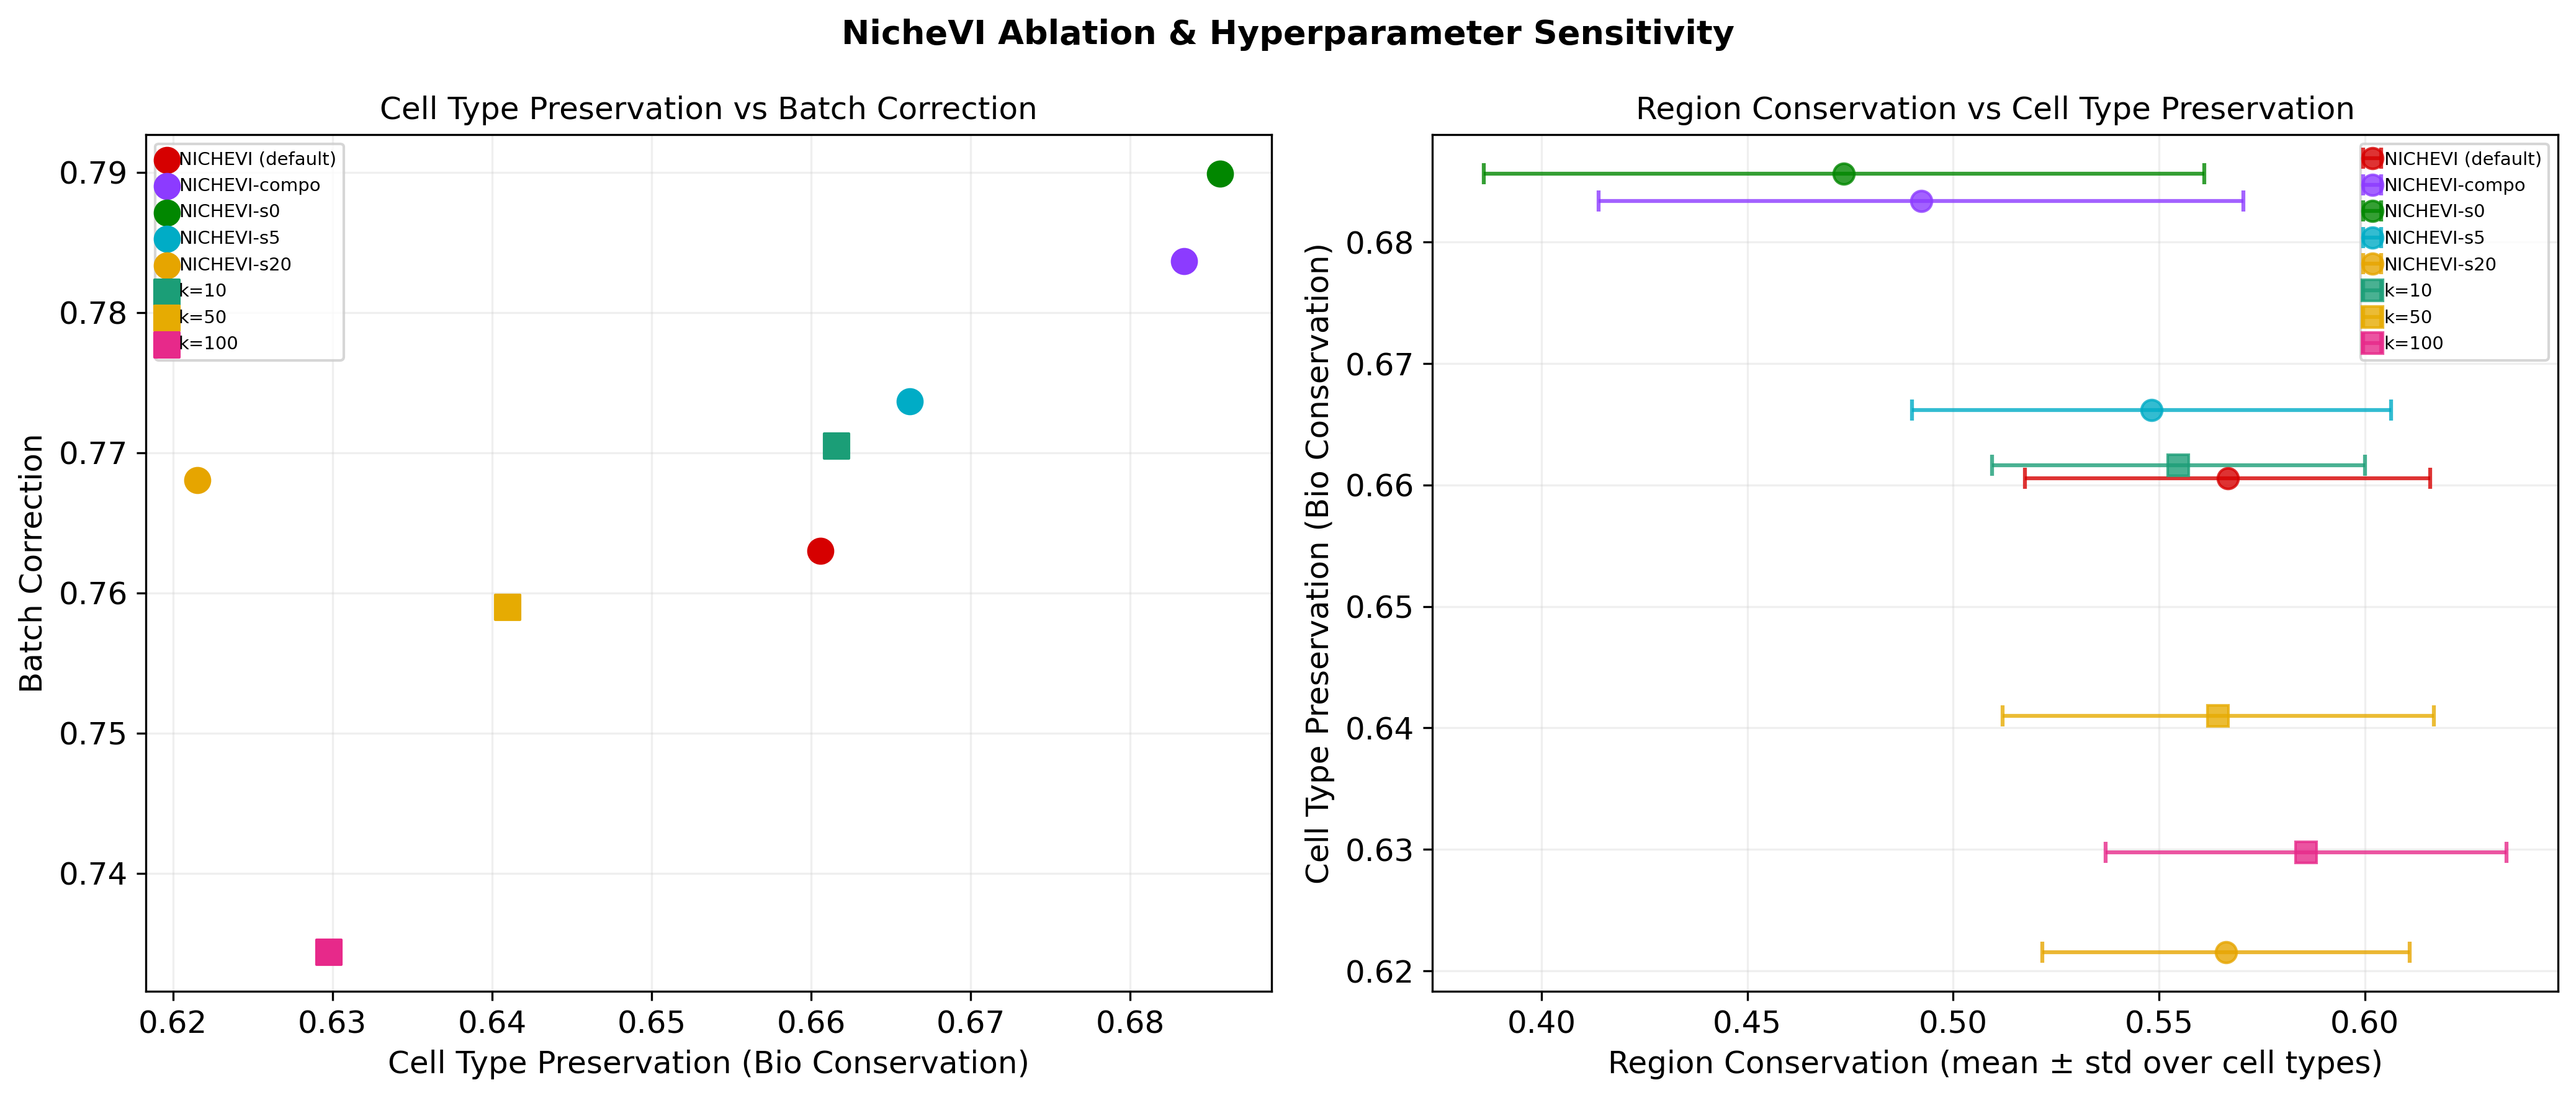

,Bio conservation,Batch correction,Region conservation
Embedding,,,
NICHEVI (default),0.660566,0.763011,0.566682
NICHEVI-compo,0.683384,0.783666,0.492232
NICHEVI-s0,0.685641,0.789915,0.473464
NICHEVI-s5,0.666168,0.773665,0.548192
NICHEVI-s20,0.621515,0.768037,0.566271
k=10,0.661609,0.770457,0.554716
k=50,0.640993,0.758971,0.564377
k=100,0.629762,0.734340,0.585741


In [2]:
rename = {
    "s10_scanvi_lr0.0005_poisson_X_nicheVI": "NICHEVI (default)",
    "eta0_scanvi_lr0.0005_poisson_X_nicheVI": "NICHEVI-compo",
    "s0_scanvi_lr0.0005_poisson_X_nicheVI": "NICHEVI-s0",
    "s5_scanvi_lr0.0005_poisson_X_nicheVI": "NICHEVI-s5",
    "s20_scanvi_lr0.0005_poisson_X_nicheVI": "NICHEVI-s20",
    "k10_s10_scanvi_lr0.0005_poisson_X_nicheVI": "k=10",
    "k50_s10_scanvi_lr0.0005_poisson_X_nicheVI": "k=50",
    "k100_s10_scanvi_lr0.0005_poisson_X_nicheVI": "k=100",
}

df_DE_k = pd.read_csv(f"{TABLES}/BioCons_cell_type_adata_M1_M2_core_6_sections_ablation_k.csv", index_col=0).rename(columns=rename)
df_summary = read_scib(f"{TABLES}/scib_cell_type_results_adata_M1_M2_core_6_sections_ablation_k.csv").rename(index=rename)

ct_cons = df_summary["Bio conservation"]
bc = df_summary["Batch correction"]
region_mean = df_DE_k.mean(axis=0)
region_std = df_DE_k.std(axis=0)

# colors and markers
ablation_methods = ["NICHEVI (default)", "NICHEVI-compo", "NICHEVI-s0", "NICHEVI-s5", "NICHEVI-s20"]
k_methods = ["k=10", "k=50", "k=100"]
abl_colors = dict(zip(ablation_methods, cc.glasbey_dark[: len(ablation_methods)]))
k_colors = dict(zip(k_methods, ["#1b9e77", "#e6ab02", "#e7298a"]))


def get_color(m):
    return abl_colors.get(m, k_colors.get(m, "gray"))


def get_marker(m):
    return "s" if m in k_methods else "o"


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# cell type preservation vs batch correction
ax = axes[0]
for method in ct_cons.index:
    ax.scatter(ct_cons[method], bc[method], color=get_color(method), marker=get_marker(method), label=method, s=90, zorder=3)
ax.set_xlabel("Cell Type Preservation (Bio Conservation)")
ax.set_ylabel("Batch Correction")
ax.set_title("Cell Type Preservation vs Batch Correction")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)

# region conservation vs cell type preservation (xerr = std over cell types)
ax = axes[1]
for method in region_mean.index.intersection(ct_cons.index):
    ax.errorbar(region_mean[method], ct_cons[method], xerr=region_std[method], fmt=get_marker(method), color=get_color(method),
                label=method, markersize=8, capsize=4, capthick=1.5, elinewidth=1.5, alpha=0.8)
ax.set_xlabel("Region Conservation (mean ± std over cell types)")
ax.set_ylabel("Cell Type Preservation (Bio Conservation)")
ax.set_title("Region Conservation vs Cell Type Preservation")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)

plt.suptitle("NicheVI Ablation & Hyperparameter Sensitivity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ablation_k.png", dpi=500)
plt.savefig(f"{FIGURES_DIR}/ablation_k.svg", dpi=500)
plt.show()
df_summary[["Bio conservation", "Batch correction"]].assign(**{"Region conservation": region_mean})

## Fig. S2: scVIVA trained on Leiden pseudo-labels

### A: scVI embedding, colored by cell type and by the Leiden clusters at each resolution

17 Leiden clusters at resolution 0.15
25 Leiden clusters at resolution 0.35


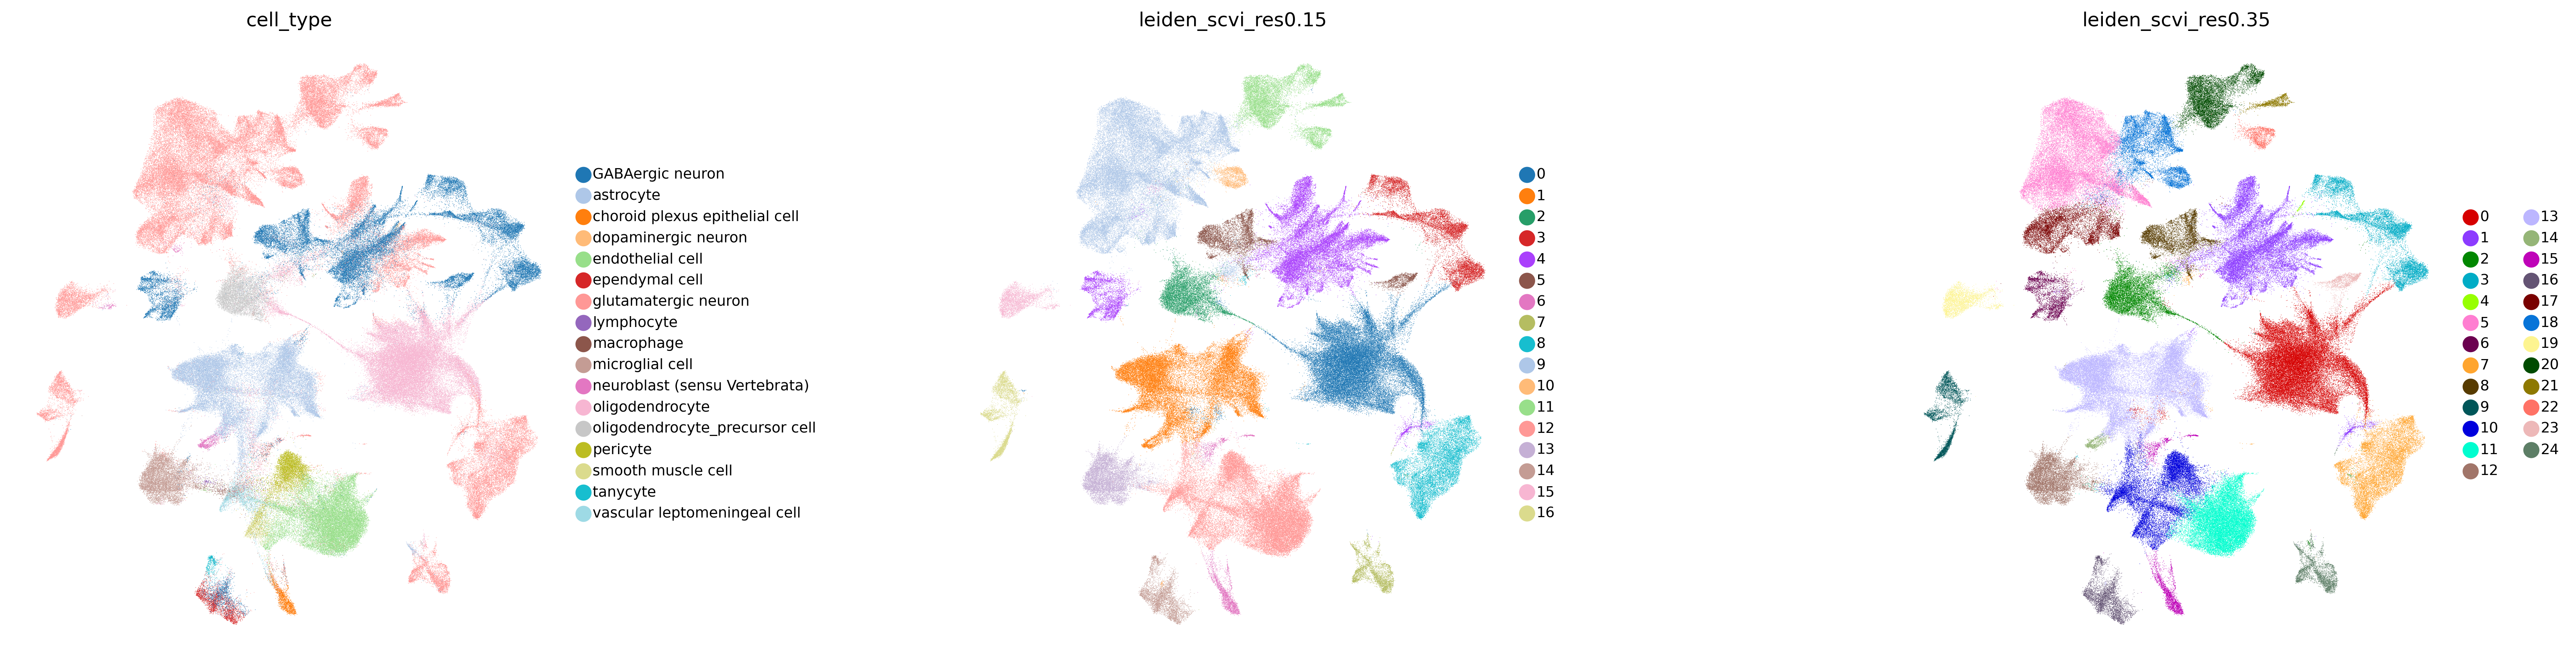

In [3]:
adata = sc.read_h5ad(f"{REPO}/merfish_brain/checkpoints/adata_M1_M2_core_6_sections/adata_M1_M2_core_6_sections_nolabel_nicheVI.h5ad")
for res in FIGURE_RES:
    key = f"leiden_scvi_res{res}"
    n = adata.obs[key].nunique()
    print(n, "Leiden clusters at resolution", res)
    adata.uns[f"{key}_colors"] = (cc.glasbey if n > 20 else sc.pl.palettes.default_20)[:n]

sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.umap(adata, min_dist=0.3, random_state=0)
keys = ["cell_type"] + [f"leiden_scvi_res{r}" for r in FIGURE_RES]
fig, axes = plt.subplots(1, len(keys), figsize=(9 * len(keys), 7))
for ax, key in zip(axes, keys):
    sc.pl.umap(adata, color=key, ax=ax, frameon=False, show=False)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5), ncol=2 if len(labels) > 17 else 1,
              fontsize=9, frameon=False, markerscale=1.5)
fig.subplots_adjust(wspace=0.7)
plt.savefig(f"{FIGURES_DIR}/X_scVI_umap_nolabel.png", bbox_inches="tight", dpi=500)
plt.savefig(f"{FIGURES_DIR}/X_scVI_umap_nolabel.svg", bbox_inches="tight", dpi=500)
plt.show()

### B and C: labeled vs unlabeled scVIVA (scIB scores computed with the original cell type labels)

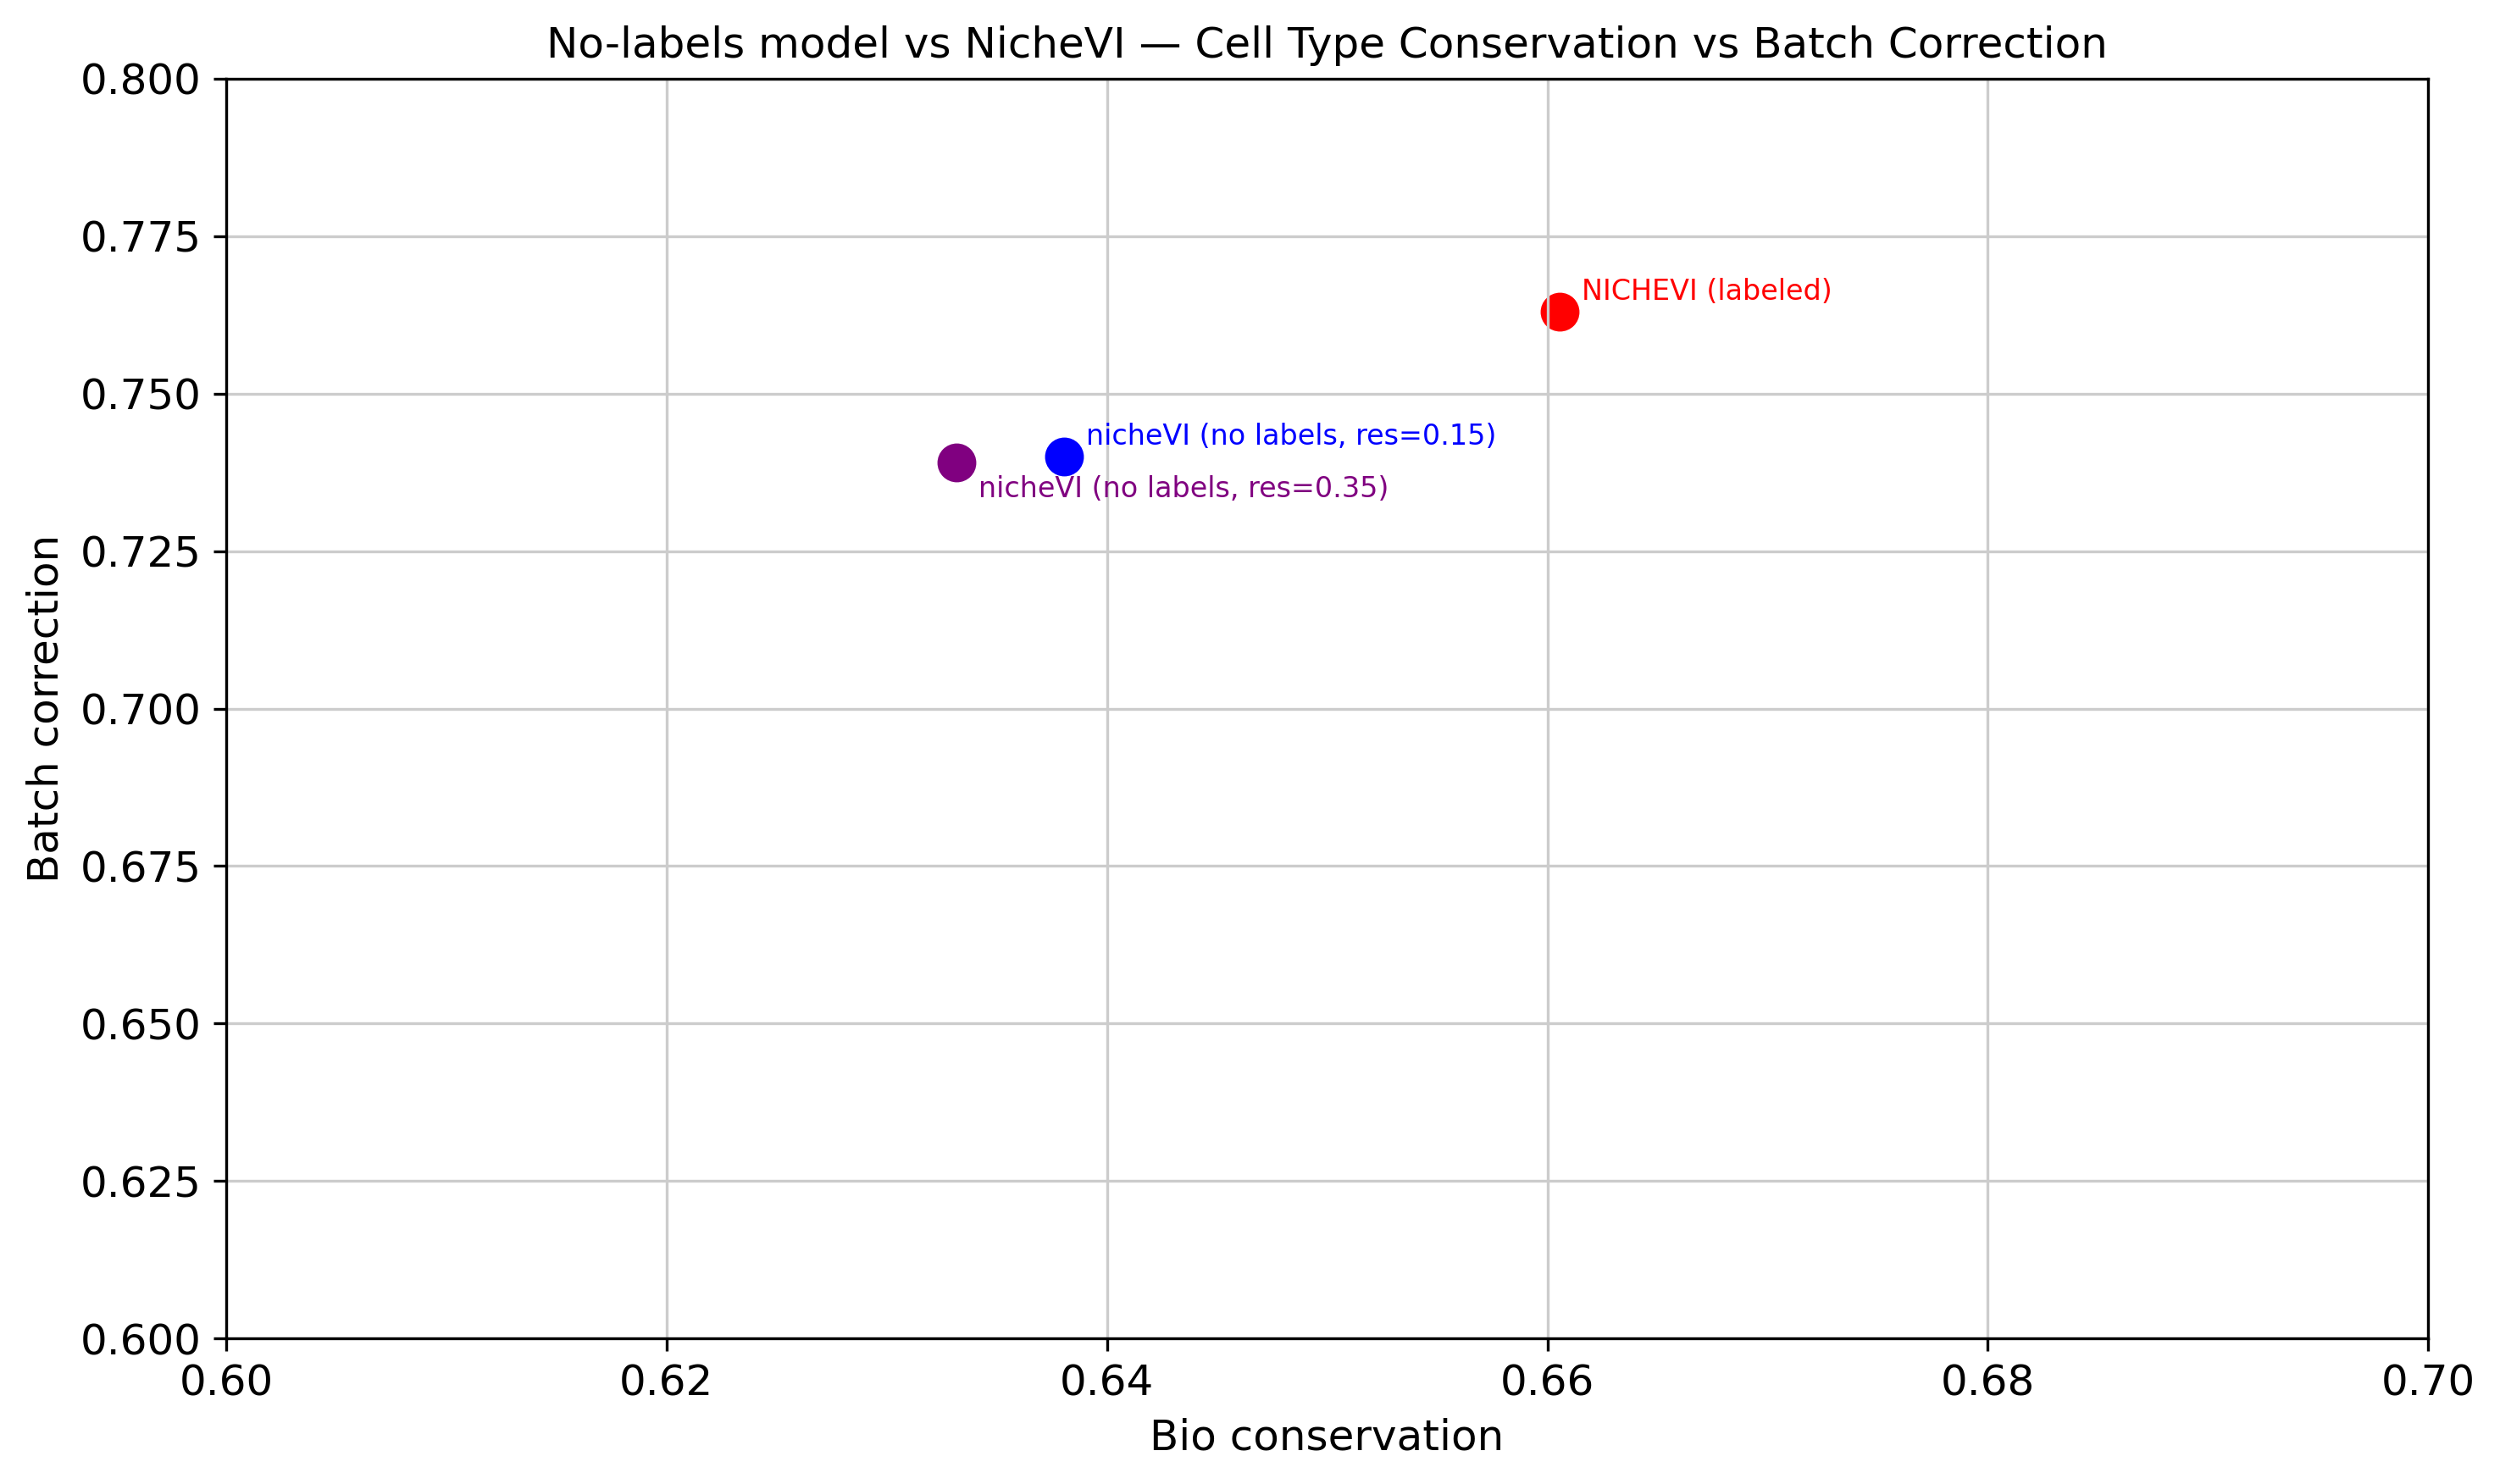

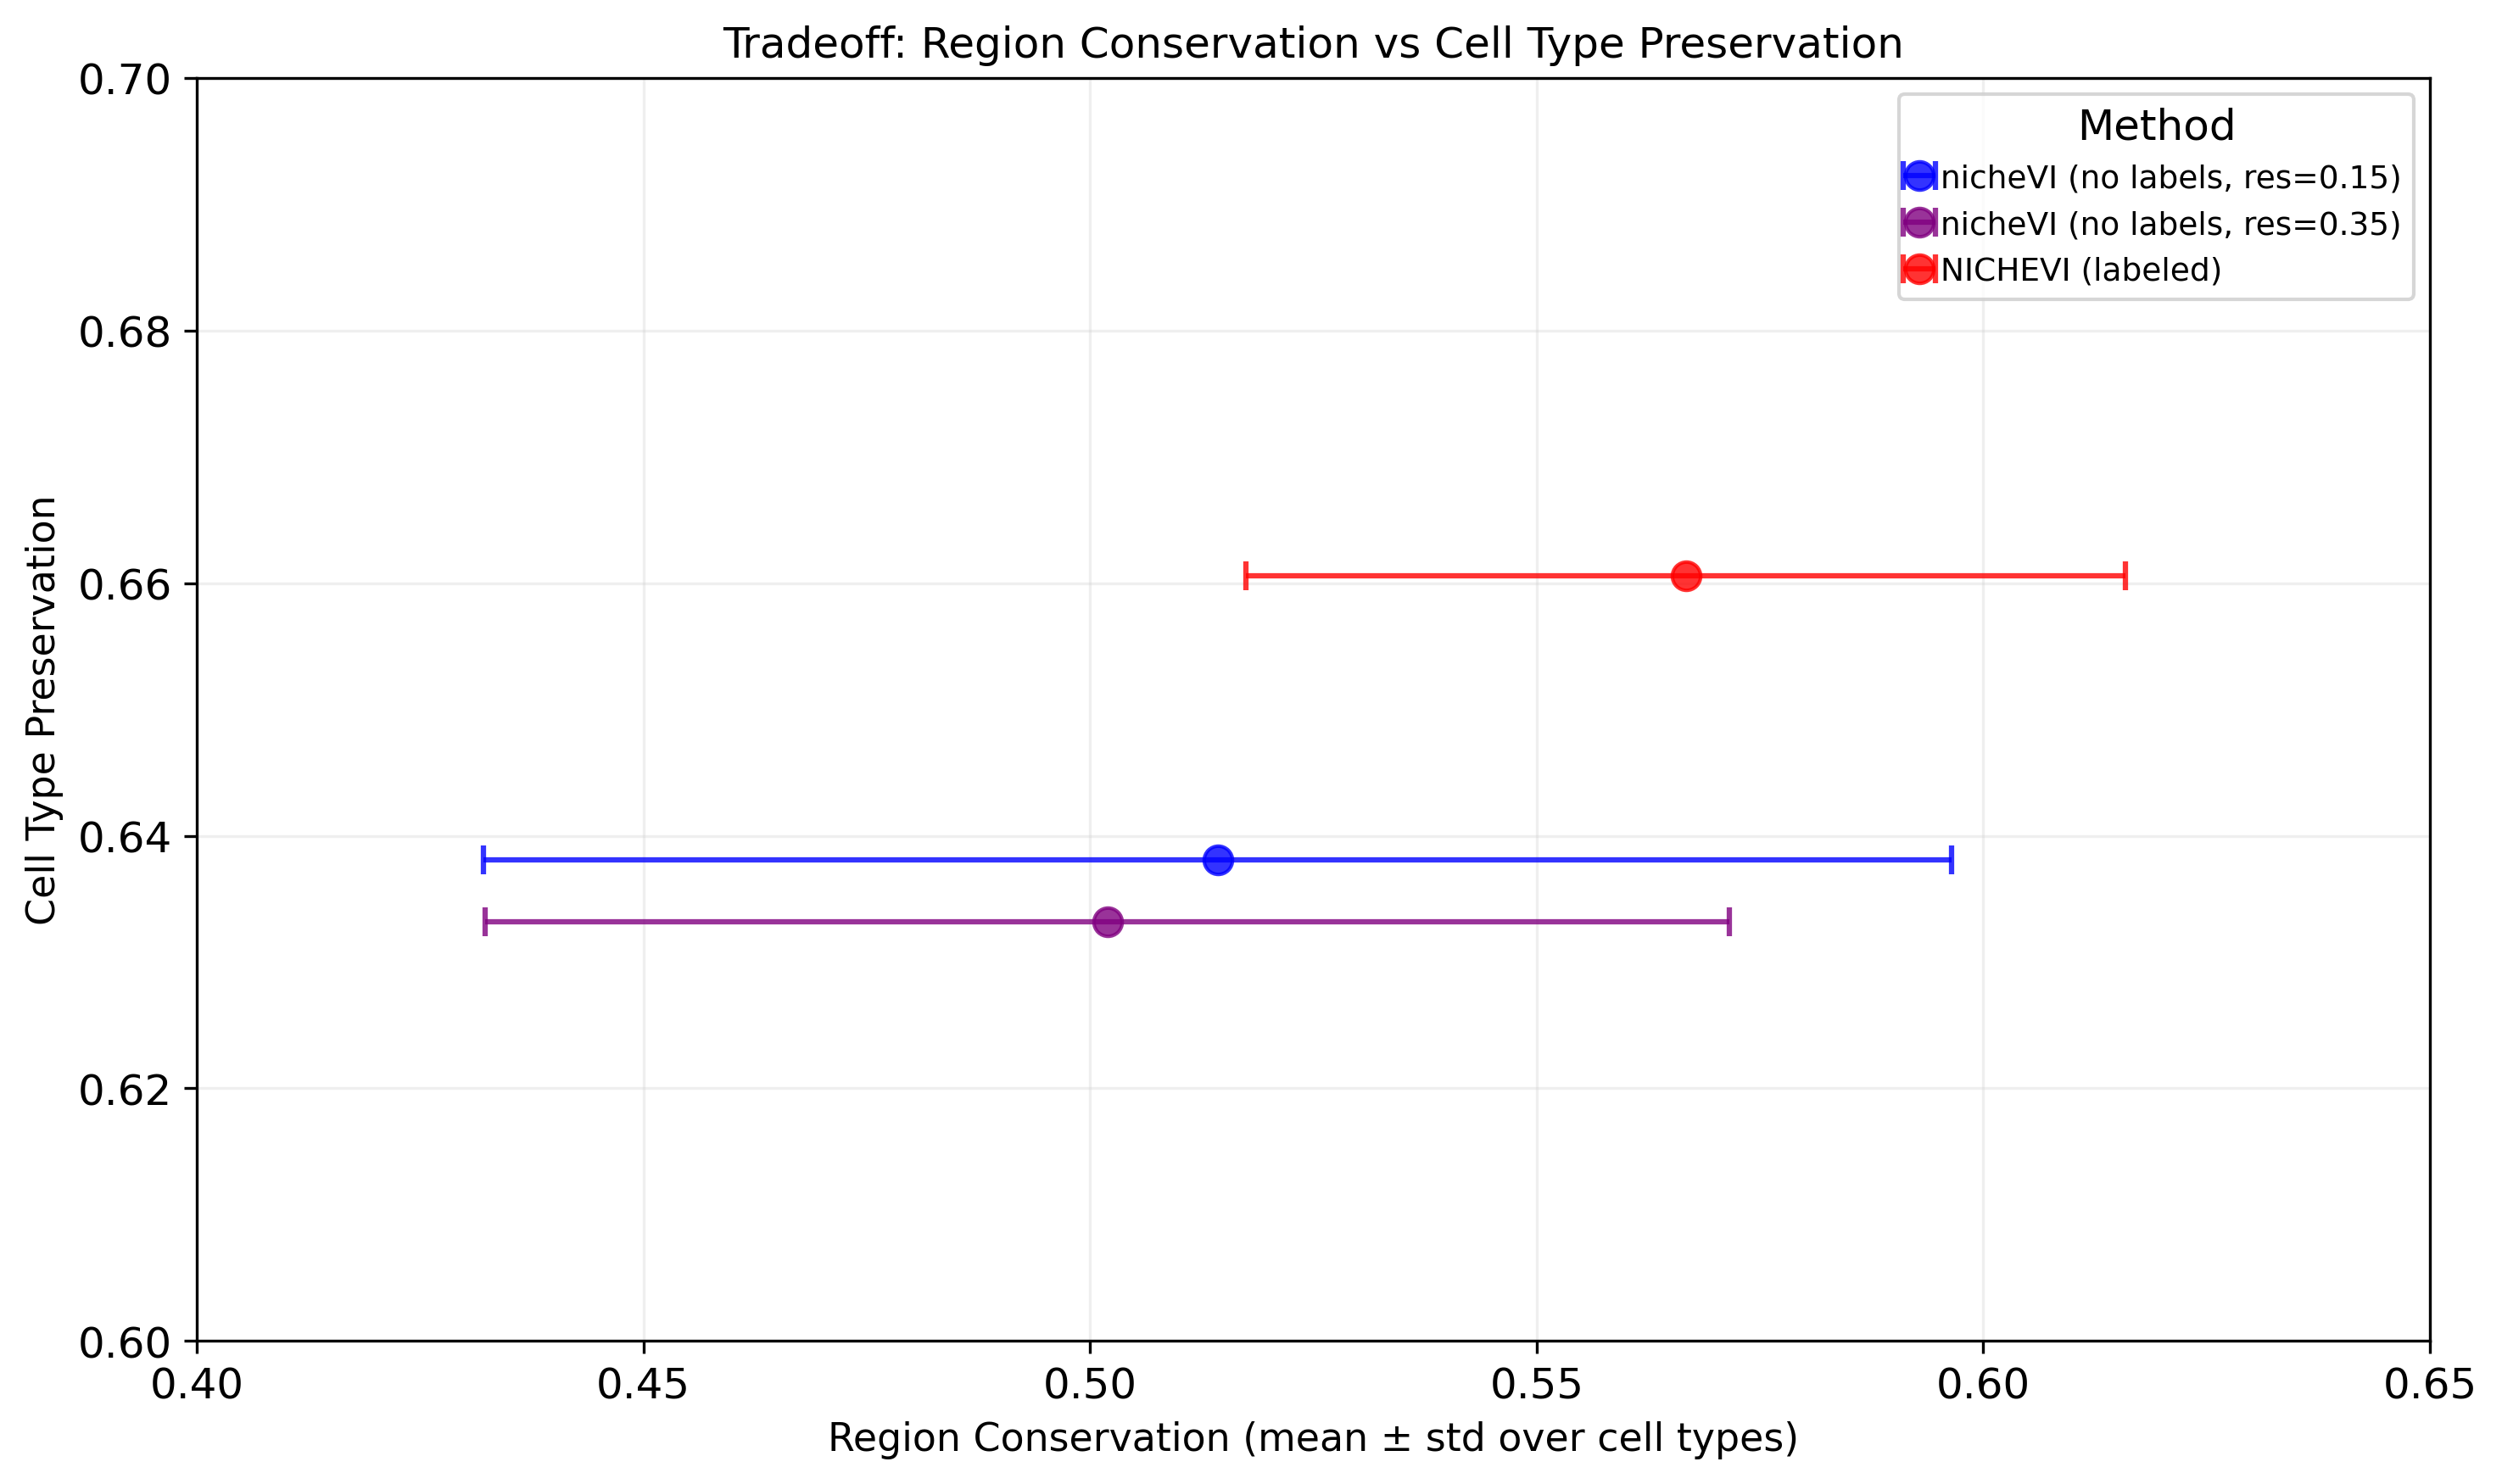

,bio,bc,reg,reg_std
"nicheVI (no labels, res=0.15)",0.63806,0.739984,0.514271,0.082184
"nicheVI (no labels, res=0.35)",0.633172,0.739026,0.501937,0.06967
NICHEVI (labeled),0.660566,0.763011,0.566682,0.049193


In [4]:
nolabel = read_scib(f"{TABLES}/scib_cell_type_results_ablation_nolabel.csv")
labeled = read_scib(f"{FIGURE_2}/scib_cell_type_results_adata_M1_M2_core_6_sections.csv").loc[NICHEVI_KEY]
labeled_region = pd.read_csv(f"{FIGURE_2}/BioCons_cell_type_adata_M1_M2_core_6_sections.csv", index_col=0)[NICHEVI_KEY]

UNLABELED_COLORS = {0.15: "blue", 0.35: "purple"}
points = {}
for res in FIGURE_RES:
    key = f"{res}_s10_scvi_lr0.0005_poisson_X_nicheVI"
    region = pd.read_csv(f"{TABLES}/BioCons_cell_type_ablation_nolabel_res{res}.csv", index_col=0)[key]
    points[f"nicheVI (no labels, res={res})"] = dict(color=UNLABELED_COLORS.get(res, "gray"), bio=nolabel.loc[key, "Bio conservation"],
                                                     bc=nolabel.loc[key, "Batch correction"], reg=region.mean(), reg_std=region.std())
points["NICHEVI (labeled)"] = dict(color="red", bio=labeled["Bio conservation"], bc=labeled["Batch correction"],
                                   reg=labeled_region.mean(), reg_std=labeled_region.std())

# B: cell type conservation vs batch correction
plt.figure(figsize=(10, 6))
LABEL_BELOW = {"nicheVI (no labels, res=0.35)"}  # the two unlabeled points are close: one label above, one below
for name, p in points.items():
    plt.scatter(p["bio"], p["bc"], color=p["color"], s=100)
    below = name in LABEL_BELOW
    plt.text(p["bio"] + 0.001, p["bc"] + (-0.002 if below else 0.001), name, fontsize=8, ha="left",
             va="top" if below else "bottom", color=p["color"])
plt.xlim(0.6, 0.7)
plt.ylim(0.6, 0.8)
plt.xlabel("Bio conservation")
plt.ylabel("Batch correction")
plt.title("No-labels model vs NicheVI — Cell Type Conservation vs Batch Correction")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/nolabels_scib_scatter.png", dpi=1000)
plt.savefig(f"{FIGURES_DIR}/nolabels_scib_scatter.svg", dpi=1000)
plt.show()

# C: region conservation vs cell type preservation
fig, ax = plt.subplots(figsize=(10, 6))
for name, p in points.items():
    ax.errorbar(p["reg"], p["bio"], xerr=p["reg_std"], fmt="o", color=p["color"], label=name, markersize=8, capsize=4,
                capthick=1.5, elinewidth=1.5, alpha=0.8)
ax.set_xlim(0.4, 0.65)
ax.set_ylim(0.6, 0.7)
ax.set_xlabel("Region Conservation (mean ± std over cell types)", fontsize=11)
ax.set_ylabel("Cell Type Preservation", fontsize=11)
ax.set_title("Tradeoff: Region Conservation vs Cell Type Preservation", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title="Method", loc="best", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/nolabels_region_celltype.png", dpi=500)
plt.savefig(f"{FIGURES_DIR}/nolabels_region_celltype.svg", dpi=500)
plt.show()
pd.DataFrame(points).T.drop(columns="color")